# Basic Chat Bot
powered by `LangGraph (Graph API)`

In [1]:
# Importing libraries

from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages # REDUCERS -> appending messages (creating a history)

/Users/soubhiksinha/GitHub/Agentic-AI-LangGraph-and-MCP/.venv/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
# Creating State
from typing import Annotated

class State(TypedDict):
  messages: Annotated[list, add_messages]

In [3]:
# Loading environment variable values

import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
''' 
Defining LLMs
'''

from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

# Loading model
llm = ChatGroq(model = "llama-3.1-8b-instant")

In [5]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x11d8e5130>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11dc46060>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
# Another way of loading LLM
'''
llm = init_chat_model("groq:llama-3.1-8b-instant")
'''

'\nllm = init_chat_model("groq:llama-3.1-8b-instant")\n'

In [7]:
# Creating Node definitions

def chatbot(state:State):
  return {"messages": [llm.invoke(state["messages"])]}

In [8]:
# Creating Graph
graph_builder = StateGraph(State)

In [9]:
graph_builder.add_node("llmChatBot", chatbot)

# Adding Edge(s)
graph_builder.add_edge(START, "llmChatBot")
graph_builder.add_edge("llmChatBot", END)

In [10]:
# Compiling the Graph
graph = graph_builder.compile()

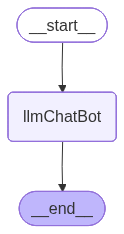

In [11]:
graph

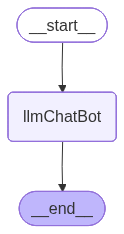

In [12]:
# Another way of showing the graph

from IPython.display import Image, display

try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [13]:
# Running the workflow (invoking)

response = graph.invoke({"messages": "Hi! This is Rick!!!"})

In [14]:
response

{'messages': [HumanMessage(content='Hi! This is Rick!!!', additional_kwargs={}, response_metadata={}, id='55dc2134-3047-47f6-b81e-d3754a695515'),
  AIMessage(content="It's great to meet you, Rick! How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 41, 'total_tokens': 58, 'completion_time': 0.031259429, 'completion_tokens_details': None, 'prompt_time': 0.006071717, 'prompt_tokens_details': None, 'queue_time': 0.030816888, 'total_time': 0.037331146}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfbae-9070-7453-8608-9009551f3ec2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 17, 'total_tokens': 58})]}

In [15]:
response["messages"]

[HumanMessage(content='Hi! This is Rick!!!', additional_kwargs={}, response_metadata={}, id='55dc2134-3047-47f6-b81e-d3754a695515'),
 AIMessage(content="It's great to meet you, Rick! How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 41, 'total_tokens': 58, 'completion_time': 0.031259429, 'completion_tokens_details': None, 'prompt_time': 0.006071717, 'prompt_tokens_details': None, 'queue_time': 0.030816888, 'total_time': 0.037331146}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfbae-9070-7453-8608-9009551f3ec2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 17, 'total_tokens': 58})]

In [16]:
response["messages"][-1]

AIMessage(content="It's great to meet you, Rick! How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 41, 'total_tokens': 58, 'completion_time': 0.031259429, 'completion_tokens_details': None, 'prompt_time': 0.006071717, 'prompt_tokens_details': None, 'queue_time': 0.030816888, 'total_time': 0.037331146}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfbae-9070-7453-8608-9009551f3ec2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 17, 'total_tokens': 58})

In [17]:
response["messages"][-1].content

"It's great to meet you, Rick! How can I assist you today?"

In [18]:
for event in graph.stream({"messages": "Hi! This is Rick!! How's everything going ?"}):
  print(event)


{'llmChatBot': {'messages': [AIMessage(content="Hi Rick, I'm doing well, thanks for asking. I'm a large language model, so I don't have emotions or personal experiences, but I'm always ready to chat and help with any questions or topics you'd like to discuss. It's great to meet you! How about you, how's your day going?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 46, 'total_tokens': 113, 'completion_time': 0.130214817, 'completion_tokens_details': None, 'prompt_time': 0.003015729, 'prompt_tokens_details': None, 'queue_time': 0.005554982, 'total_time': 0.133230546}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfbae-9157-7572-87cf-7d423ff13dd7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 67, 'total_tokens': 113})]}}


In [19]:
for event in graph.stream({"messages": "Hi! This is Rick!! How's everything going ?"}):
  for value in event.values():
    print(value["messages"][-1].content)

Hi Rick! It's great to meet you. I'm a large language model, so I don't have personal experiences or emotions, but I'm here to help you with any questions or topics you'd like to discuss. How can I assist you today?


<br>

## Chat-Bot with Tool(s)

In [20]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
tool.invoke("WHat is LangGraph ?")

{'query': 'WHat is LangGraph ?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions. By treating workflows as interconnected nodes and edges, LangGraph offers a scalable, transparent and developer-friendly way to design advanced AI systems ranging from simple chatbots to multi-agent system. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. By designing workflows, users combine multiple nodes into powerful, dynamic AI processes. * ****langgraph:**** Framework for bu

In [21]:
# Creating a custom function

def multiply(a: int, b: int) -> int:
  """Multiply a and b

  Args:
    a (int) : first int
    b (int) : second int
  
  Returns:
    int: output int
  """
  return a*b


In [22]:
tools = [tool, multiply]

In [23]:
llm_with_tool = llm.bind_tools(tools)

In [24]:
llm_with_tool

RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x11d8e5130>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11dc46060>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, acc

In [25]:
# StateGraph

from langgraph.prebuilt import ToolNode, tools_condition

In [26]:
# The above created functions must be converted to Tool Nodes

# Node Defintion
def tool_calling_llm(state: State):
  return {"messages" :[llm_with_tool.invoke(state["messages"])]}

# Creating the Graph (Adding Nodes)
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Adding Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
  "tool_calling_llm",
  # If the latest message (result) from assistant is a tool call --> tools_condition routes to tools
  # If the latest message (result) from assistant is a NOT a tool call --> tools_condition routes to END
  tools_condition
)
builder.add_edge("tools", END)

# Compiling the graph
graph = builder.compile()

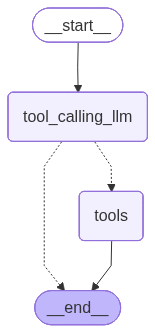

In [27]:
graph

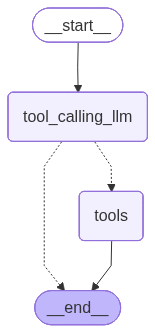

In [28]:
# Showing the graph another way

from IPython.display import Image, display

try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [29]:
# Invoke the graph (workflow)

response = graph.invoke({"messages" : "What are the recent advances in Agentic AI ?"})

In [30]:
response

{'messages': [HumanMessage(content='What are the recent advances in Agentic AI ?', additional_kwargs={}, response_metadata={}, id='d50416f4-3914-4a4c-9166-d1be2aad143d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '2er9qhss4', 'function': {'arguments': '{"query":"recent advances in agentic AI","start_date":"2024-01-01","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 's8bm3g6gf', 'function': {'arguments': '{"a":3,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 1755, 'total_tokens': 1812, 'completion_time': 0.095556046, 'completion_tokens_details': None, 'prompt_time': 0.209815616, 'prompt_tokens_details': {'cached_tokens': 512}, 'queue_time': 0.058495917, 'total_time': 0.305371662}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'},

In [31]:
response["messages"][-1].content

'9'

In [32]:
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

What are the recent advances in Agentic AI ?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (2er9qhss4)
 Call ID: 2er9qhss4
  Args:
    query: recent advances in agentic AI
    start_date: 2024-01-01
    topic: news
  multiply (s8bm3g6gf)
 Call ID: s8bm3g6gf
  Args:
    a: 3
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "recent advances in agentic AI", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/tonybradley/2025/10/08/when-machines-think-in-context/", "title": "When Machines Think In Context - Forbes", "score": 0.81204927, "published_date": "Wed, 08 Oct 2025 14:48:11 GMT", "content": "Agentic AI represents a new class of systems that can reason, collaborate and act independently toward defined goals—marking

In [33]:
response1 = graph.invoke({"messages" : "2 X 3 = ?"})

In [34]:
response1

{'messages': [HumanMessage(content='2 X 3 = ?', additional_kwargs={}, response_metadata={}, id='e68dd0f0-09a2-4c46-a1d1-a0d1da81858d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4w6sngj43', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1751, 'total_tokens': 1770, 'completion_time': 0.036046357, 'completion_tokens_details': None, 'prompt_time': 0.321683375, 'prompt_tokens_details': None, 'queue_time': 0.065712116, 'total_time': 0.357729732}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfbae-c991-7573-8745-6716141e79f4-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '4w6sngj43', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1751, 'output_tokens':

In [35]:
response1["messages"][-1].content

'6'

In [36]:
for m in response1["messages"]:
  m.pretty_print()

================================ Human Message =================================

2 X 3 = ?
================================== Ai Message ==================================
Tool Calls:
  multiply (4w6sngj43)
 Call ID: 4w6sngj43
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [37]:
response2 = graph.invoke({"messages" : "What is 2 multiplied by 5 and then multipled by 100 ? - go step by step"})
for m in response2["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 5 and then multipled by 100 ? - go step by step
================================== Ai Message ==================================
Tool Calls:
  multiply (ekbcfxpkv)
 Call ID: ekbcfxpkv
  Args:
    a: 2
    b: 5
  multiply (3j7e8amq1)
 Call ID: 3j7e8amq1
  Args:
    a: 10
    b: 100
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

1000


In [38]:
response3 = graph.invoke({"messages" : "What is the latest news by Apple Inc. and what is 2 multiplied by 5 and then multipled by 100 ? - go step by step"})
for m in response3["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is the latest news by Apple Inc. and what is 2 multiplied by 5 and then multipled by 100 ? - go step by step
================================== Ai Message ==================================
Tool Calls:
  tavily_search (676t82850)
 Call ID: 676t82850
  Args:
    query: Apple Inc latest news
    search_depth: advanced
    topic: news
  tavily_search (hv7vnsdwg)
 Call ID: hv7vnsdwg
  Args:
    query: Apple Inc latest news
    search_depth: advanced
    topic: news
  multiply (75wps0zaf)
 Call ID: 75wps0zaf
  Args:
    a: 2
    b: 5
  multiply (xdzw9e6ns)
 Call ID: xdzw9e6ns
  Args:
    a: 50
    b: 100
================================= Tool Message =================================
Name: tavily_search

{"query": "Apple Inc latest news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://nypost.com/2026/04/30/business/apple-iphone-powers-quarterly-sales-to-111b-demand

<br>

## ReAct Agent Architecture

In [39]:
# Recreating the graph structure - following ReAct agent architecture (Reasoning + Act) : Act + Observe + React

# Creating the Graph (Adding Nodes)
builder1 = StateGraph(State)
builder1.add_node("tool_calling_llm", tool_calling_llm)
builder1.add_node("tools", ToolNode(tools))

# Adding Edges
builder1.add_edge(START, "tool_calling_llm")
builder1.add_conditional_edges(
  "tool_calling_llm",
  # If the latest message (result) from assistant is a tool call --> tools_condition routes to tools
  # If the latest message (result) from assistant is a NOT a tool call --> tools_condition routes to END
  tools_condition
)
builder1.add_edge("tools", "tool_calling_llm")

# Compiling the graph
graph1 = builder1.compile()

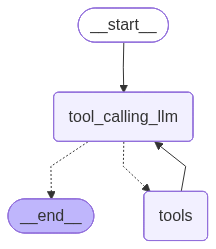

In [40]:
graph1

In [41]:
response4 = graph1.invoke({"messages" : "What is 2 multiplied by 5 and then multipled by 100 ? - go step by step"})
for m in response4["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 5 and then multipled by 100 ? - go step by step
================================== Ai Message ==================================
Tool Calls:
  multiply (vjjypx5mt)
 Call ID: vjjypx5mt
  Args:
    a: 2
    b: 5
  multiply (dz3w605mt)
 Call ID: dz3w605mt
  Args:
    a: 10
    b: 100
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

1000
================================== Ai Message ==================================

So, 2 multiplied by 5 is 10, and 10 multiplied by 100 is 1000.


In [42]:
response5 = graph1.invoke({"messages" : "What is the latest news by Apple Inc. and what is 2 multiplied by 5 and then multipled by 100 ? - go step by step"})
for m in response5["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is the latest news by Apple Inc. and what is 2 multiplied by 5 and then multipled by 100 ? - go step by step
================================== Ai Message ==================================
Tool Calls:
  tavily_search (36ey8vr4w)
 Call ID: 36ey8vr4w
  Args:
    end_date: None
    exclude_domains: []
    include_domains: []
    include_images: False
    query: latest news apple inc
    search_depth: advanced
    start_date: None
    time_range: None
    topic: news
  multiply (38k1dmhnn)
 Call ID: 38k1dmhnn
  Args:
    a: 2
    b: 5
  multiply (4vzspwtw7)
 Call ID: 4vzspwtw7
  Args:
    a: 10
    b: 100
================================= Tool Message =================================
Name: tavily_search

{"query": "latest news apple inc", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.apple.com/newsroom/2026/04/apple-reports-second-quarter-results/", "title"

<br>

## Adding Memory in Agentic Graph

In [43]:
response6 = graph1.invoke({"messages" : "Hi! This is Rick!!"})
for m in response6["messages"]:
  m.pretty_print()

================================ Human Message =================================

Hi! This is Rick!!
================================== Ai Message ==================================

Nice to meet you, Rick. What can I help you with today?


In [44]:
response7 = graph1.invoke({"messages" : "What is my name ?"})
for m in response7["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is my name ?
================================== Ai Message ==================================

I don't have any information about your name. If you would like to provide it, I can try to help you with a specific question or task.


In [45]:
'''
You see, the conversation is never stored / recorded - i.e., no persistency on conversation (memory)
'''

'\nYou see, the conversation is never stored / recorded - i.e., no persistency on conversation (memory)\n'

In [46]:
# Working around the same graph that we used before

from langgraph.checkpoint.memory import MemorySaver

# Creating the memory object
memory = MemorySaver()

# Creating the Graph (Adding Nodes)
builder2 = StateGraph(State)
builder2.add_node("tool_calling_llm", tool_calling_llm)
builder2.add_node("tools", ToolNode(tools))

# Adding Edges
builder2.add_edge(START, "tool_calling_llm")
builder2.add_conditional_edges(
  "tool_calling_llm",
  # If the latest message (result) from assistant is a tool call --> tools_condition routes to tools
  # If the latest message (result) from assistant is a NOT a tool call --> tools_condition routes to END
  tools_condition
)
builder2.add_edge("tools", "tool_calling_llm")

# Compiling the graph
graph2 = builder2.compile(checkpointer = memory)

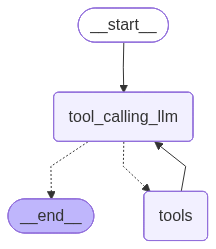

In [47]:
graph2

In [48]:
'''
For creating memory (say for a session) - we need a Thread ID
Thread ID is responsbile to uniquely identify every other session
'''

config = {"configurable" : {"thread_id" : "1"}}

response_memory = graph2.invoke({"messages" : "Hi! This is Soubhik Sinha!!"}, config = config)
response_memory


{'messages': [HumanMessage(content='Hi! This is Soubhik Sinha!!', additional_kwargs={}, response_metadata={}, id='fcc1e566-535f-4313-920b-71b7f542a940'),
  AIMessage(content="Nice to meet you, Soubhik Sinha! It's great to have you here. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 1756, 'total_tokens': 1784, 'completion_time': 0.035546258, 'completion_tokens_details': None, 'prompt_time': 0.165996134, 'prompt_tokens_details': None, 'queue_time': 0.00957079, 'total_time': 0.201542392}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfbb1-5d25-7bc0-b5ea-c4cf2f02605c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1756, 'output_tokens': 28, 'total_tokens': 1784})]}

In [49]:
response_memory["messages"][-1].content

"Nice to meet you, Soubhik Sinha! It's great to have you here. How can I assist you today?"

In [50]:
response_memory = graph2.invoke({"messages" : "What is my name ?"}, config = config)

response_memory["messages"][-1].content

'Soubhik Sinha'

In [51]:
response_memory = graph2.invoke({"messages" : "Do you still remember my name ?"}, config = config)

response_memory["messages"][-1].content

'I remember that your name is Soubhik Sinha.'

<br>

## Streaming

In [52]:
'''
Streaming in a LangGraph agentic workflow refers to the capability to receive real-time, incremental updates as an agent executes, rather than waiting for the entire process to finish
'''

'\nStreaming in a LangGraph agentic workflow refers to the capability to receive real-time, incremental updates as an agent executes, rather than waiting for the entire process to finish\n'

In [53]:
def superBot(state: State):
  return {"messages": [llm.invoke(state["messages"])]}

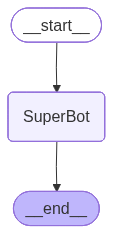

In [54]:
# Creating the graph

graph3 = StateGraph(State)

# Creating memory object
memory_1 = MemorySaver()

# Adding nodes
graph3.add_node("SuperBot", superBot)

# Adding Edges
graph3.add_edge(START, "SuperBot")
graph3.add_edge("SuperBot", END)

# Compiling the Graph
graph_builder_1 = graph3.compile(checkpointer = memory_1)

# Displaying the graph
graph_builder_1

In [55]:
# Invocation using creation of thread

config_1 = {"configurable" : {"thread_id": "1"}}

graph_builder_1.invoke({"messages" : "Hi! This is Rick!! I am an AI Engineer"}, config = config)

{'messages': [HumanMessage(content='Hi! This is Rick!! I am an AI Engineer', additional_kwargs={}, response_metadata={}, id='ff7356cd-b915-4743-bc43-f08ddb187ca3'),
  AIMessage(content='Nice to meet you, Rick the AI Engineer. What brings you here today? Are you working on a new project or looking for some help with an existing one?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 46, 'total_tokens': 80, 'completion_time': 0.052221537, 'completion_tokens_details': None, 'prompt_time': 0.010044356, 'prompt_tokens_details': None, 'queue_time': 0.177753453, 'total_time': 0.062265893}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d9492c3c54', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfbb2-3236-7862-b9b7-bee2e366f12f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 34, 'total_tokens': 80})]}

In [56]:
# Creating a thread

config_2 = {"configurable" : {"thread_id": "2"}}

# Mode = "updates"
for chunk in graph_builder_1.stream({"messages" : "Hi! This is Rick!! I am an AI Engineer"}, config_2, stream_model = "updates"):
  print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Rick! As an AI Engineer, that's really cool. What kind of projects have you been working on? Are you into natural language processing, computer vision, or something else?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 46, 'total_tokens': 88, 'completion_time': 0.058354689, 'completion_tokens_details': None, 'prompt_time': 0.003099025, 'prompt_tokens_details': None, 'queue_time': 0.009378328, 'total_time': 0.061453714}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfbb2-337f-75c2-a760-81fff55d54dd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 42, 'total_tokens': 88})]}}


In [57]:
# Mode = "values"
for chunk in graph_builder_1.stream({"messages" : "Hi! This is Rick!! I am an AI Engineer"}, config_2, stream_model = "values"):
  print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Nice to meet you, Rick. As an AI Engineer, you must be working with some exciting technologies. What specific area of AI are you most interested in or currently working with?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 108, 'total_tokens': 145, 'completion_time': 0.083190647, 'completion_tokens_details': None, 'prompt_time': 0.010696917, 'prompt_tokens_details': None, 'queue_time': 0.006164174, 'total_time': 0.093887564}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfbb2-3413-71f3-87fb-3520b85be2df-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 108, 'output_tokens': 37, 'total_tokens': 145})]}}


In [58]:
'''
In LangGraph, streaming means the agent workflow sends live outputs while it is still running instead of waiting for the entire workflow to finish. 

The difference between updates and values is simple: 

- Updates only streams the things that changed after each step/node, making it lightweight and efficient for real-time apps.
- Values streams the entire current state of the workflow every time a step completes, which is more verbose but useful for debugging and observing the full agent state. 

Think of it like this: updates says “here’s what was newly added,” whereas values says “here’s the complete latest snapshot of everything right now.”
'''

'\nIn LangGraph, streaming means the agent workflow sends live outputs while it is still running instead of waiting for the entire workflow to finish. \n\nThe difference between updates and values is simple: \n\n- Updates only streams the things that changed after each step/node, making it lightweight and efficient for real-time apps.\n- Values streams the entire current state of the workflow every time a step completes, which is more verbose but useful for debugging and observing the full agent state. \n\nThink of it like this: updates says “here’s what was newly added,” whereas values says “here’s the complete latest snapshot of everything right now.”\n'

In [59]:
config_3 = {"configurable" : {"thread_id": "3"}}

for chunk in graph_builder_1.stream({"messages" : "Hi! This is Rick!! I am an AI Engineer"}, config_3, stream_model = "values"):
  print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Rick! Welcome to our conversation. As an AI Engineer, I'm sure you're passionate about designing and developing intelligent systems that can learn and adapt. What specific areas of AI are you interested in or working on?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 46, 'total_tokens': 95, 'completion_time': 0.08538883, 'completion_tokens_details': None, 'prompt_time': 0.003718758, 'prompt_tokens_details': None, 'queue_time': 0.135429754, 'total_time': 0.089107588}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d9492c3c54', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfbb2-3910-7481-a21e-e10ef4926720-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 49, 'total_tokens': 95})]}}


In [60]:
for chunk in graph_builder_1.stream({"messages" : "I love Road-Tripping!!!"}, config_3, stream_model = "updates"):
  print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Road-tripping is an amazing way to explore new places and experience the thrill of the open road. There's something special about traveling with the freedom to create your own itinerary and take in the sights along the way.\n\nSo, Rick the AI Engineer who loves road-tripping, I have to ask: Have you ever thought about combining your passions for AI and road-tripping? Perhaps you could develop an app or system that helps plan the perfect road trip, or even use machine learning to optimize routes and recommend scenic stops?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 105, 'prompt_tokens': 111, 'total_tokens': 216, 'completion_time': 0.207400734, 'completion_tokens_details': None, 'prompt_time': 0.007868595, 'prompt_tokens_details': None, 'queue_time': 0.006401699, 'total_time': 0.215269329}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_rea

In [62]:
# Using `astream_events()` for asynchronous execution

config_4 = {"configurable" : {"thread_id": "4"}}

async for chunk in graph_builder_1.astream_events({"messages" : "Hi! This is Rick!! I am an AI Engineer"}, config_4, version="v2"):
  print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi! This is Rick!! I am an AI Engineer'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019dfbbb-ecba-78c1-831a-59dcbbf0144f', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi! This is Rick!! I am an AI Engineer', additional_kwargs={}, response_metadata={}, id='3024534f-94ea-477a-88f9-57a5ebd4ffe3')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019dfbbb-ecbc-77f1-99b2-ecf25926510c', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:aea9ca7d-5c25-72dd-72b9-6f10c7af5bc0'}, 'parent_ids': ['019dfbbb-ecba-78c1-831a-59dcbbf0144f']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(co